<a href="https://colab.research.google.com/github/ThiagoSDomingues/PINNs-for-heavy-ion-collisions/blob/main/BDNK_PINN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load the BDNK Background Simulations folder

In [1]:
import os

# Clone the repository
!git clone https://github.com/vchomalicastro/1-1D-BDNK-diffusion-simulations.git

# Define the source and destination paths
source_path = '/content/1-1D-BDNK-diffusion-simulations/(1+1)D BDNK Diffusion - SA-PINN-ACTO/BDNK Background Simulations'
destination_path = '/content/BDNK Background Simulations'

# Move the folder
if os.path.exists(source_path):
    # Ensure the destination directory exists if it's a new name
    os.makedirs(os.path.dirname(destination_path), exist_ok=True)
    # Use shutil.move for moving directories
    import shutil
    shutil.move(source_path, destination_path)
    print(f"Moved '{source_path}' to '{destination_path}'")
else:
    print(f"Source path '{source_path}' does not exist. Please check the repository structure.")

# Clean up the cloned repository to keep the environment tidy
!rm -rf /content/1-1D-BDNK-diffusion-simulations

Cloning into '1-1D-BDNK-diffusion-simulations'...
remote: Enumerating objects: 405, done.
remote: Counting objects: 100% (98/98), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 405 (delta 52), reused 16 (delta 14), pack-reused 307 (from 1)
Receiving objects: 100% (405/405), 76.80 MiB | 27.55 MiB/s, done.
Resolving deltas: 100% (117/117), done.
Moved '/content/1-1D-BDNK-diffusion-simulations/(1+1)D BDNK Diffusion - SA-PINN-ACTO/BDNK Background Simulations' to '/content/BDNK Background Simulations'


Installing latex in matplotlib

In [2]:
import matplotlib
import matplotlib.pyplot as plt

# Install TeX Live packages for LaTeX support
!apt-get update
!apt-get install -y texlive-latex-recommended texlive-fonts-recommended dvipng

# Configure Matplotlib to use LaTeX
matplotlib.rcParams['text.usetex'] = True
matplotlib.rcParams['text.latex.preamble'] = '\\usepackage{amsmath}'

print("LaTeX setup for Matplotlib complete.")

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:7 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [88.5 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,497 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,963 kB]
Hit:13 https://ppa.launchpadcontent.net

In [3]:
import time

# Device configuration and core PyTorch setup
import torch
import torch.nn as nn
import torch.nn.functional as F
DTYPE = torch.float32
device = torch.device('cuda')
if device.type == "cuda":
    torch.cuda.init()
    torch.rand(1, device=device)
print(f"Using device: {device}")

from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
from SA_PINN_ACTO import PINN_BDNK_1D
from IC_1D import IC_BDNK

# Hyperparameters for network architecture and training schedule
Nl, Nn = 10, 70
t_end = 10.0
L = 50.0
adam_epochs = 20_000
lr_net = 5e-3
lr_mask = 4e-2

# BDNK simulation configuration and background field setup
from BDNK_Functions import *
BDNK_simulation = 2
setup_external_Tv(BDNK_simulation, L)

# Sampling parameters and domain sampling
N_colloc = 15000
# In the ACTO case, the N_ic below are not collocation points where an IC residual will be computed,
# but points at which the exact initial condition gets computed
N_ic = 1000

def lhs_box(n, low, high, rng=np.random):
    low, high = np.asarray(low, float), np.asarray(high, float)
    D = low.size
    H = np.empty((n, D), float)
    for j in range(D):
        P = (rng.permutation(n) + rng.rand(n)) / n
        H[:, j] = low[j] + P * (high[j] - low[j])
    return H

X_colloc_np = lhs_box(N_colloc, low=np.array([0.0, -L]), high=np.array([t_end, L])).astype(np.float32)

# Construction of initial condition sampling grid
x_edges = np.linspace(-L, L, N_ic+1)
x_ic = (0.5 * (x_edges[:-1] + x_edges[1:])).reshape(-1, 1)
t_ic = np.zeros_like(x_ic)
X_ic = np.hstack((t_ic, x_ic))

X_ic_t = torch.tensor(X_ic, dtype=DTYPE, device=device)
J0_ic_t, alpha_ic_t, _ = IC_BDNK(X_ic_t, L)

# Scaling factors for numerical stability of IC enforcement
with torch.no_grad():
    sJ0 = J0_ic_t.abs().max().clamp_min(1e-12).item()
    sA  = alpha_ic_t.abs().max().clamp_min(1e-12).item()
print(f"[scales] sJ0={sJ0:.3e}, sA={sA:.3e}")

# Sorting IC data to enable fast 1D interpolation
x_ic_torch = X_ic_t[:, 1:2].contiguous().view(-1)
x_sorted, idx_sort = torch.sort(x_ic_torch)
J0_sorted    = J0_ic_t.view(-1)[idx_sort]
alpha_sorted = alpha_ic_t.view(-1)[idx_sort]

@torch.no_grad()
def _torch_lin_interp_1d(xq: torch.Tensor, x: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    xq_flat = xq.view(-1)
    xq_clamped = xq_flat.clamp(min=x[0], max=x[-1])
    idx_hi = torch.searchsorted(x, xq_clamped, right=True)
    idx_hi = idx_hi.clamp(min=1, max=x.numel() - 1)
    idx_lo = idx_hi - 1
    x0 = x[idx_lo]; x1 = x[idx_hi]
    y0 = y[idx_lo]; y1 = y[idx_hi]
    denom = (x1 - x0)
    denom = torch.where(denom.abs() > 0, denom, torch.ones_like(denom))
    w = (xq_clamped - x0) / denom
    yq = y0 + w * (y1 - y0)
    return yq.view_as(xq)

# Initial condition functions passed to the neural network (physical scale)
def J0_ic_func(x_phys: torch.Tensor) -> torch.Tensor:
    if x_sorted.device != x_phys.device or x_sorted.dtype != x_phys.dtype:
        xk = x_sorted.to(device=x_phys.device, dtype=x_phys.dtype)
        yk = J0_sorted.to(device=x_phys.device, dtype=x_phys.dtype)
    else:
        xk, yk = x_sorted, J0_sorted
    yq = _torch_lin_interp_1d(x_phys.view(-1), xk, yk)
    return yq.view(-1, 1)

def alpha_ic_func(x_phys: torch.Tensor) -> torch.Tensor:
    if x_sorted.device != x_phys.device or x_sorted.dtype != x_phys.dtype:
        xk = x_sorted.to(device=x_phys.device, dtype=x_phys.dtype)
        yk = alpha_sorted.to(device=x_phys.device, dtype=x_phys.dtype)
    else:
        xk, yk = x_sorted, alpha_sorted
    yq = _torch_lin_interp_1d(x_phys.view(-1), xk, yk)
    return yq.view(-1, 1)

# Scaled initial condition functions (used internally by the model)
def J0_ic_func_scaled(x_phys: torch.Tensor) -> torch.Tensor:
    return J0_ic_func(x_phys) / sJ0

def alpha_ic_func_scaled(x_phys: torch.Tensor) -> torch.Tensor:
    return alpha_ic_func(x_phys) / sA

X_colloc = torch.tensor(X_colloc_np, dtype=DTYPE, device=device)
x0_line = torch.linspace(-L, L, 500, dtype=DTYPE, device=device).unsqueeze(1)
X0 = torch.cat([torch.zeros_like(x0_line), x0_line], dim=1)
X_colloc = torch.cat([X_colloc, X0], dim=0)

# Self-adaptive collocation mask (learned weighting of PDE residual)
pde_logits = torch.nn.Parameter(torch.zeros((X_colloc.shape[0], 1), dtype=DTYPE, device=device))
def current_masks(detach: bool = False):
    pde = F.softplus(pde_logits)
    return pde.detach() if detach else pde

# Model instantiation and domain normalization
lb = torch.tensor([0.0, -L], dtype=DTYPE, device=device)
ub = torch.tensor([t_end,  L], dtype=DTYPE, device=device)
model = PINN_BDNK_1D(Nl=Nl, Nn=Nn, lb=lb, ub=ub).to(device).to(DTYPE)
model.J0_ic_func    = J0_ic_func_scaled
model.alpha_ic_func = alpha_ic_func_scaled
model.sJ0.copy_(torch.tensor(sJ0, dtype=DTYPE, device=device))
model.sA.copy_(torch.tensor(sA,  dtype=DTYPE, device=device))

# Weight initialization
def glorot_normal_all_linear(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=1.0)
        if m.bias is not None: nn.init.zeros_(m.bias)
model.apply(glorot_normal_all_linear)

# Optimizers and learning-rate scheduler setup
optimizer_theta = torch.optim.Adam(model.parameters(), lr=lr_net, betas=(0.9, 0.95))
scheduler = ReduceLROnPlateau(optimizer_theta, mode='min', factor=0.4, patience=700, threshold=1e-4, min_lr=lr_net/100)
optimizer_mask  = torch.optim.Adam([pde_logits], lr=lr_mask, betas=(0.7, 0.85), maximize=True)

# Setting up and executing Adam pre-training
def train_adam(model, optimizer_theta, optimizer_mask, epochs, print_every):
    print("Starting Adam pre-training (SA-PINN with hard IC)...")
    best_loss, best_state = float('inf'), None
    loss_history = []

    for epoch in range(1, epochs + 1):
        optimizer_theta.zero_grad()
        optimizer_mask.zero_grad()

        R = model.pde_residual(X_colloc)
        R1, R2 = R[:, 0:1], R[:, 1:2]

        Rnorm = torch.sqrt(R1**2 + R2**2)
        pde_mask = current_masks(detach=False)
        L_pde = (pde_mask * Rnorm).pow(2).mean()

        loss = L_pde
        if not torch.isfinite(loss): raise RuntimeError("Non-finite loss detected.")

        L_pde_phys   = (R1**2 + R2**2).mean()
        L_total_phys = L_pde_phys

        loss.backward()
        optimizer_theta.step()
        scheduler.step(L_total_phys.item())
        optimizer_mask.step()

        ltp = L_total_phys.detach().item()
        loss_history.append(ltp)
        if ltp < best_loss:
            best_loss = ltp
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        if epoch % print_every == 0 or epoch == epochs:
            with torch.no_grad():
                m_pde = current_masks(detach=True)
            print(f"Adam Epoch {epoch}/{epochs} | "
                  f"Total={loss:.3e}, PDE={L_pde.item():.3e}, <pde_mask>={m_pde.mean().item():.2f} | "
                  f"Unmasked: Total={L_total_phys:.3e}, PDE={L_pde_phys.item():.3e} | "
                  f"lr_net={optimizer_theta.param_groups[0]['lr']:.3e}")

    if best_state is not None:
        model.load_state_dict(best_state)
        with torch.enable_grad():
            R = model.pde_residual(X_colloc)
            L_pde_phys = ((R[:,0:1]**2 + R[:,1:2]**2)).mean()
        print(f"\nAdam finished. Best loss = {best_loss:.3e} | PDE={L_pde_phys.item():.4e}")

    return best_loss, loss_history, best_state

start_training = time.time()
adam_loss, adam_loss_history, best_state = train_adam(model, optimizer_theta, optimizer_mask, adam_epochs, print_every=1000)
adam_training_finished = time.time()

model.load_state_dict(best_state)

# Setting up executing L-BFGS fine-tuning
with torch.enable_grad():
    X_colloc.requires_grad_(True)
    res = model.pde_residual(X_colloc)
    init_lbfgs_loss = ((res[:,0:1]**2 + res[:,1:2]**2)).mean().detach().item()
print(f"LBFGS init unmasked PDE loss (from best Adam): {init_lbfgs_loss:.3e}")

loss_scale = 1.0 / max(init_lbfgs_loss, 1e-30)

optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(),
    lr=1.0,
    max_iter=1000,
    max_eval=1000,
    history_size=100,
    line_search_fn=None,
    tolerance_grad=1e-10,
    tolerance_change=1e-12,
)

best = {"loss": float("inf"), "state": None}
inner_curve = []

def closure():
    optimizer_lbfgs.zero_grad(set_to_none=True)
    X = X_colloc.requires_grad_(True)

    R = model.pde_residual(X)
    R1, R2 = R[:, 0:1], R[:, 1:2]
    raw = (R1.pow(2) + R2.pow(2)).mean()

    if not torch.isfinite(raw):
        print(f"NaN/Inf detected at iter {len(inner_curve)}. Exiting L-BFGS.")
        raise RuntimeError("L-BFGS_NAN")

    loss = raw * loss_scale

    raw_f = float(raw)
    if raw_f < best["loss"]:
        best["loss"] = raw_f
        best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    inner_curve.append(raw_f)

    loss.backward()
    return loss

lbfgs_training_started = time.time()
try:
    final_loss = optimizer_lbfgs.step(closure)
    final_raw = float(final_loss.item()) / loss_scale
except RuntimeError as e:
    if "L-BFGS_NAN" in str(e):
        print("L-BFGS terminated early due to NaN/Inf.")
        final_raw = float("nan")
    else:
        raise
end_training = time.time()

# Restore best L-BFGS state and record loss history
if best["state"] is not None:
    model.load_state_dict(best["state"])

lbfgs_loss_history = inner_curve

print(f"LBFGS finished. final_raw={final_raw:.4e} | best_raw={best['loss']:.4e} | inner_calls={len(inner_curve)}")

print(f"\nTotal training time: {end_training - start_training:.4f} seconds."
      f"\nAdam: {adam_training_finished - start_training:.4f} seconds. "
      f"L-BFGS: {end_training - lbfgs_training_started:.4f} seconds.")


Using device: cuda
[scales] sJ0=1.050e-03, sA=1.333e-01
Starting Adam pre-training (SA-PINN with hard IC)...
Adam Epoch 1000/20000 | Total=6.427e-01, PDE=6.427e-01, <pde_mask>=23.28 | Unmasked: Total=7.582e-04, PDE=7.582e-04 | lr_net=5.000e-03
Adam Epoch 2000/20000 | Total=2.393e-01, PDE=2.393e-01, <pde_mask>=47.57 | Unmasked: Total=1.059e-04, PDE=1.059e-04 | lr_net=5.000e-03
Adam Epoch 3000/20000 | Total=3.638e-01, PDE=3.638e-01, <pde_mask>=74.06 | Unmasked: Total=6.611e-05, PDE=6.611e-05 | lr_net=5.000e-03
Adam Epoch 4000/20000 | Total=8.777e-02, PDE=8.777e-02, <pde_mask>=100.86 | Unmasked: Total=8.756e-06, PDE=8.756e-06 | lr_net=2.000e-03
Adam Epoch 5000/20000 | Total=1.113e-01, PDE=1.113e-01, <pde_mask>=128.65 | Unmasked: Total=6.605e-06, PDE=6.605e-06 | lr_net=2.000e-03
Adam Epoch 6000/20000 | Total=1.230e-01, PDE=1.230e-01, <pde_mask>=156.44 | Unmasked: Total=4.944e-06, PDE=4.944e-06 | lr_net=2.000e-03
Adam Epoch 7000/20000 | Total=3.082e-02, PDE=3.082e-02, <pde_mask>=178.04 | Un

/tmp/ipykernel_9627/1852384386.py:238: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  raw_f = float(raw)


NaN/Inf detected at iter 602. Exiting L-BFGS.
L-BFGS terminated early due to NaN/Inf.
LBFGS finished. final_raw=nan | best_raw=4.4815e-09 | inner_calls=602

Total training time: 1949.1093 seconds.
Adam: 1886.6353 seconds. L-BFGS: 62.4458 seconds.


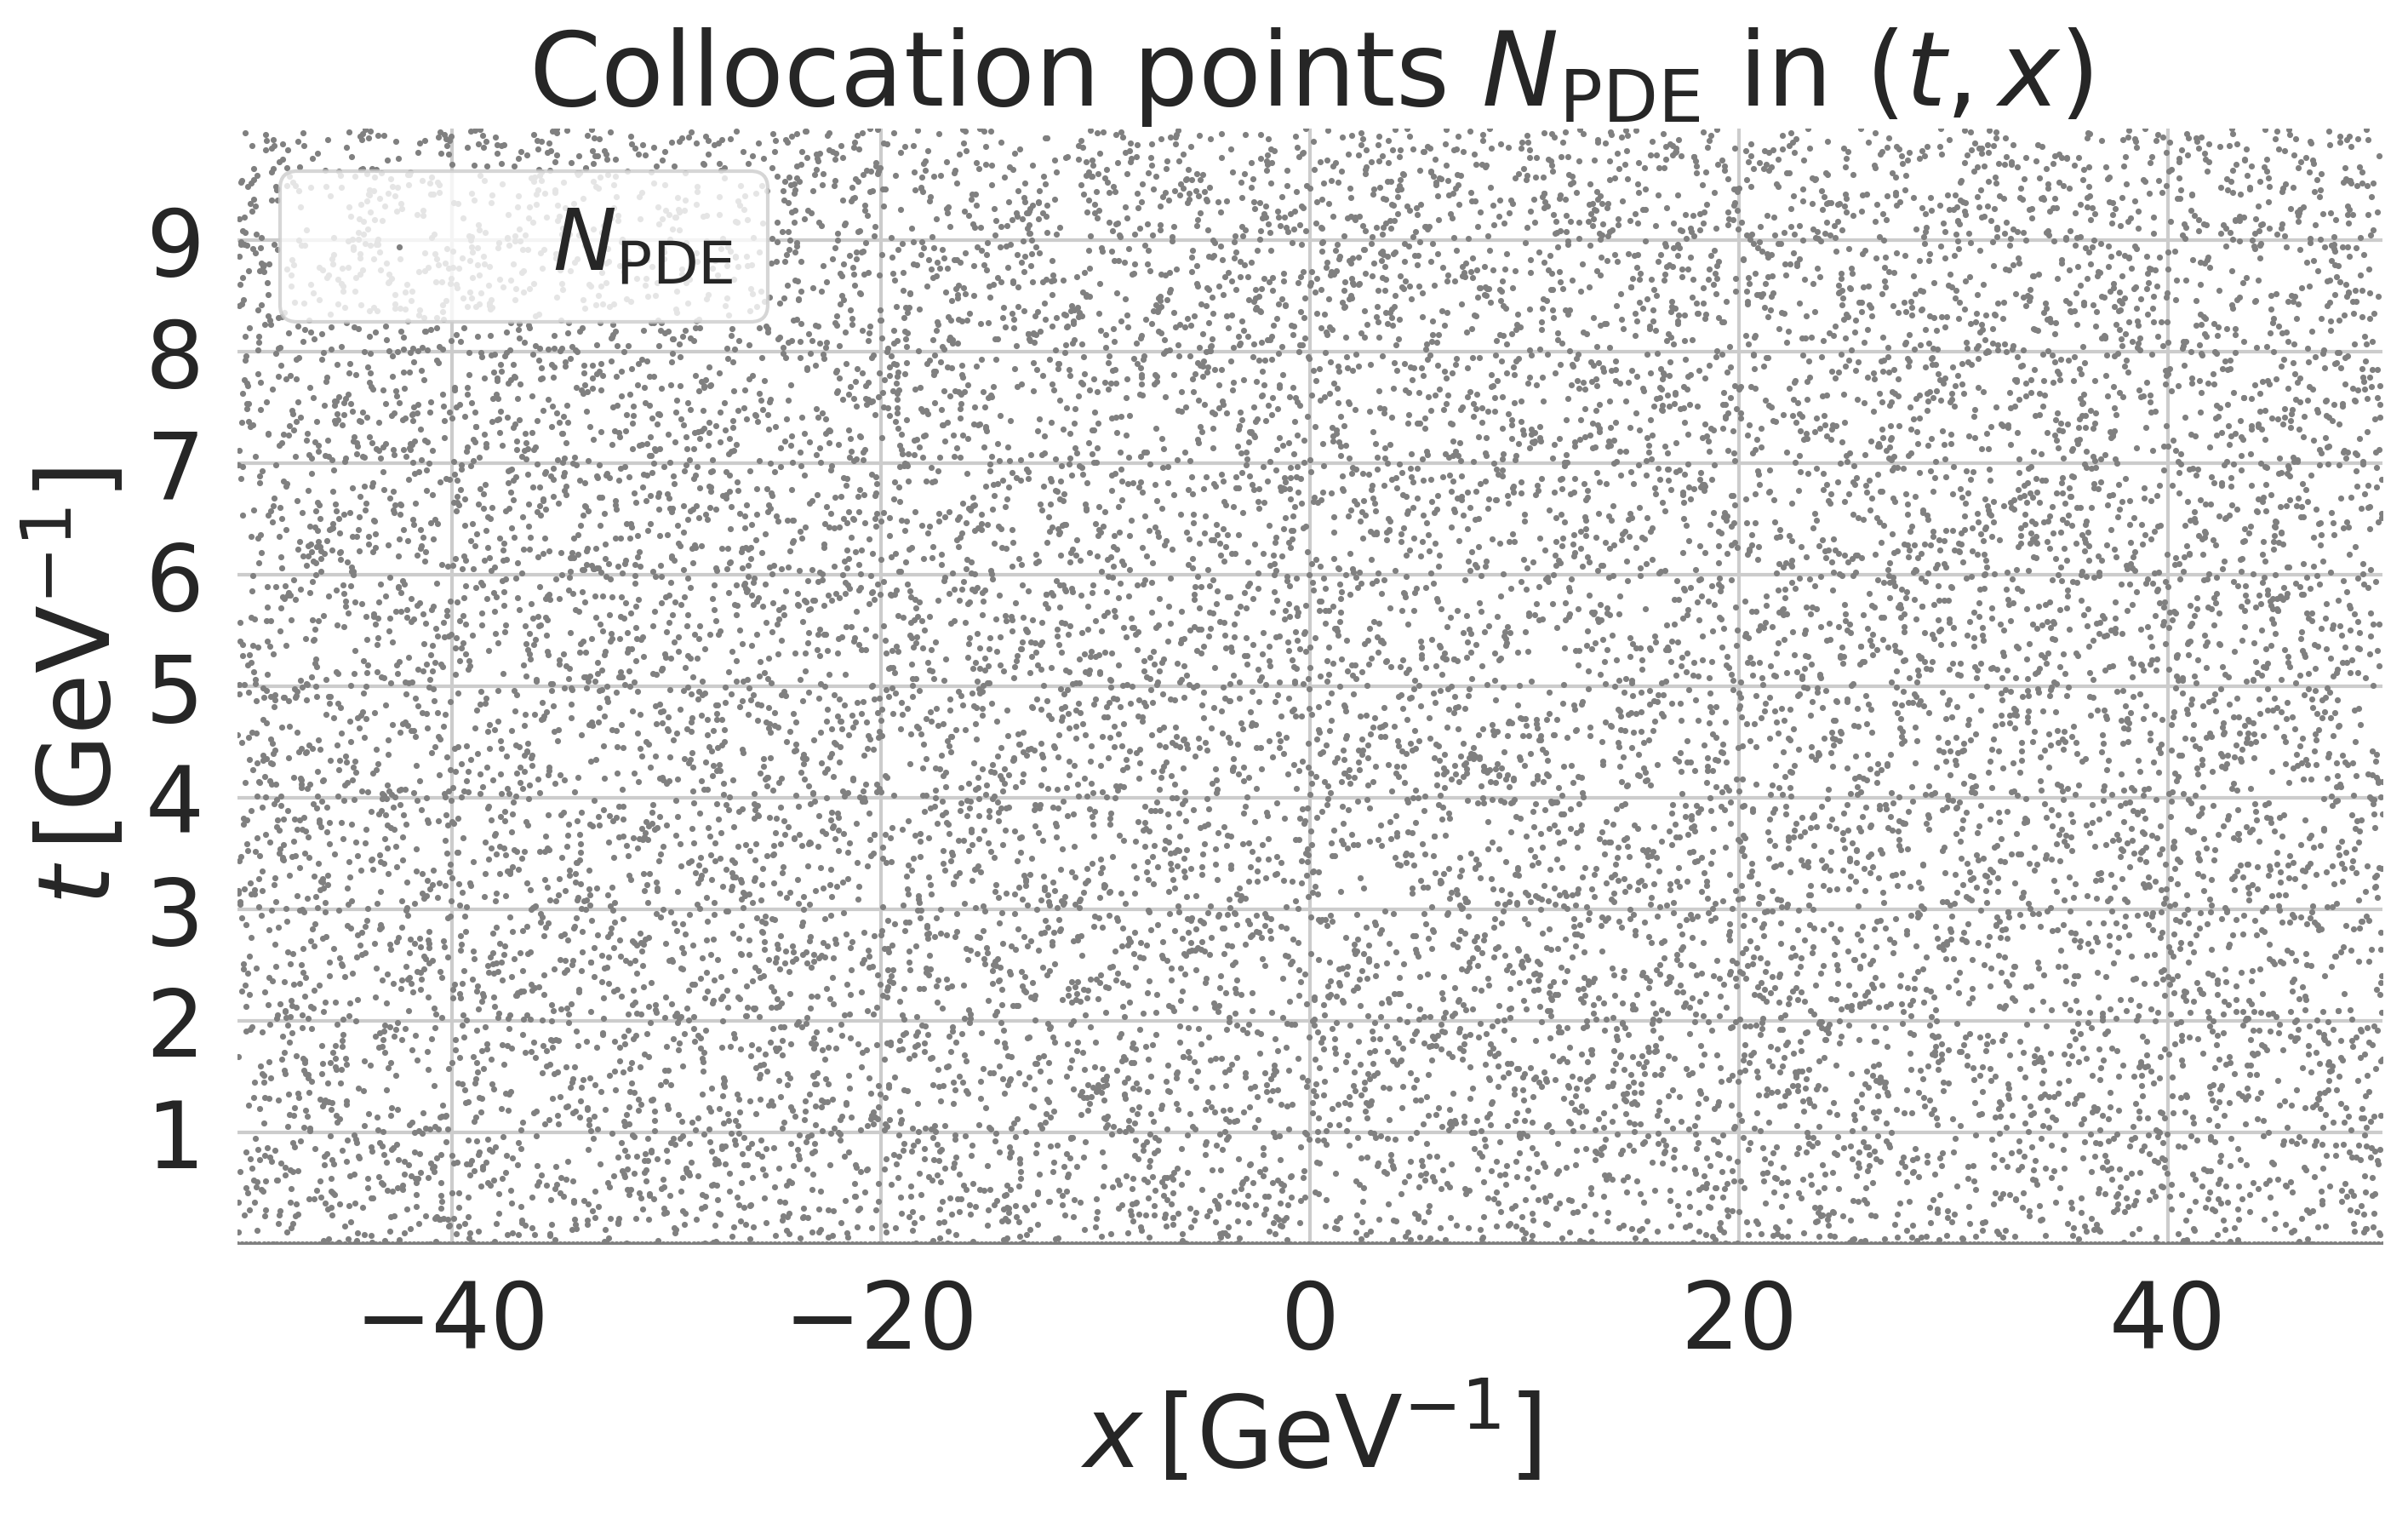

Using pre-calculated grid dump for visualization...


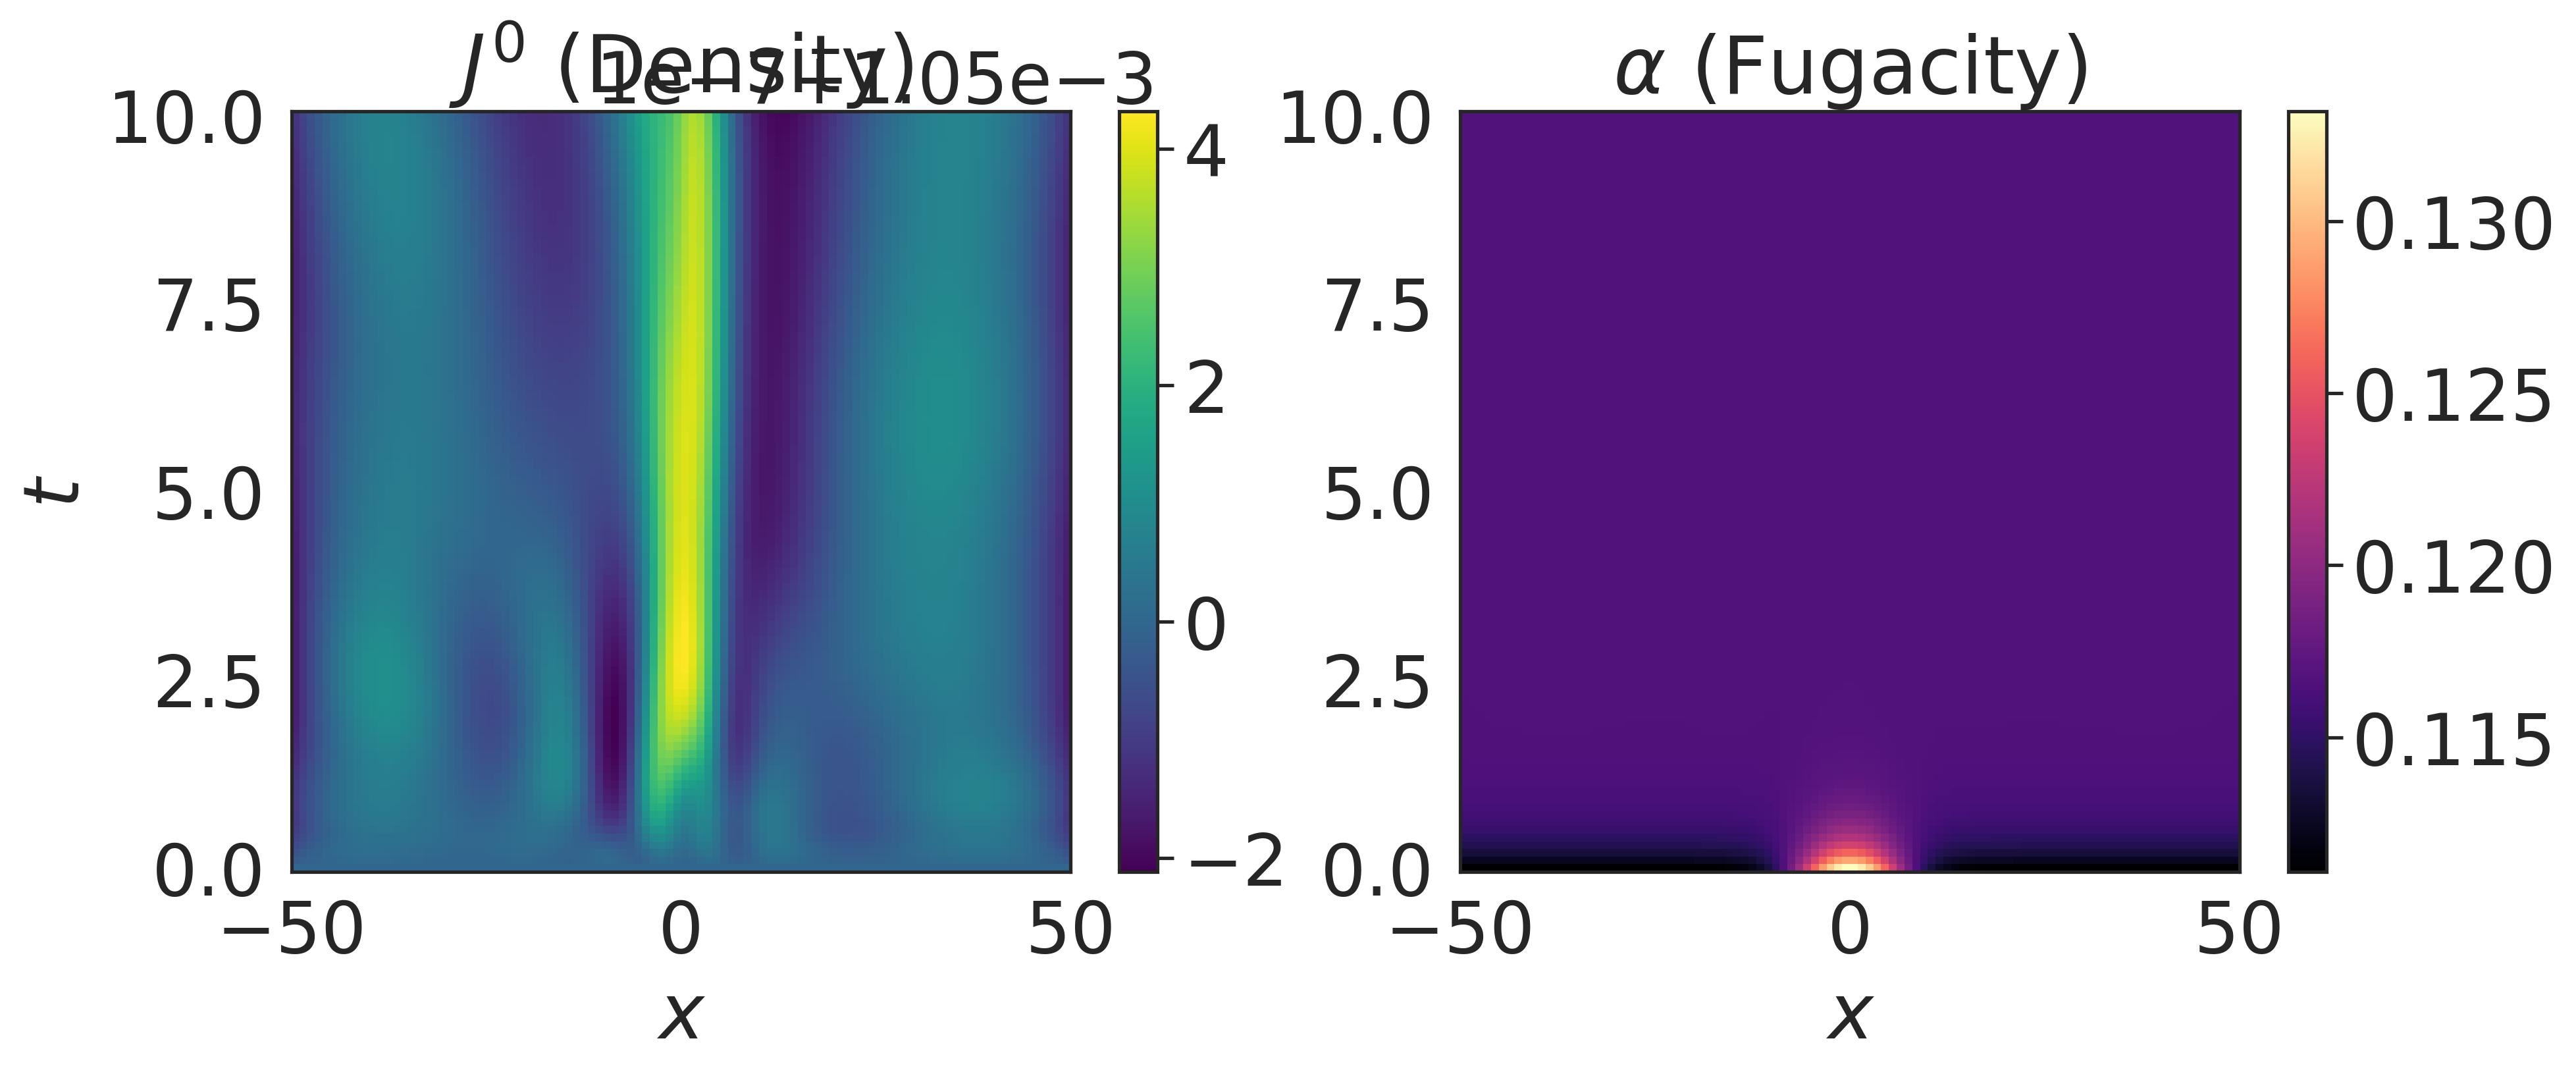

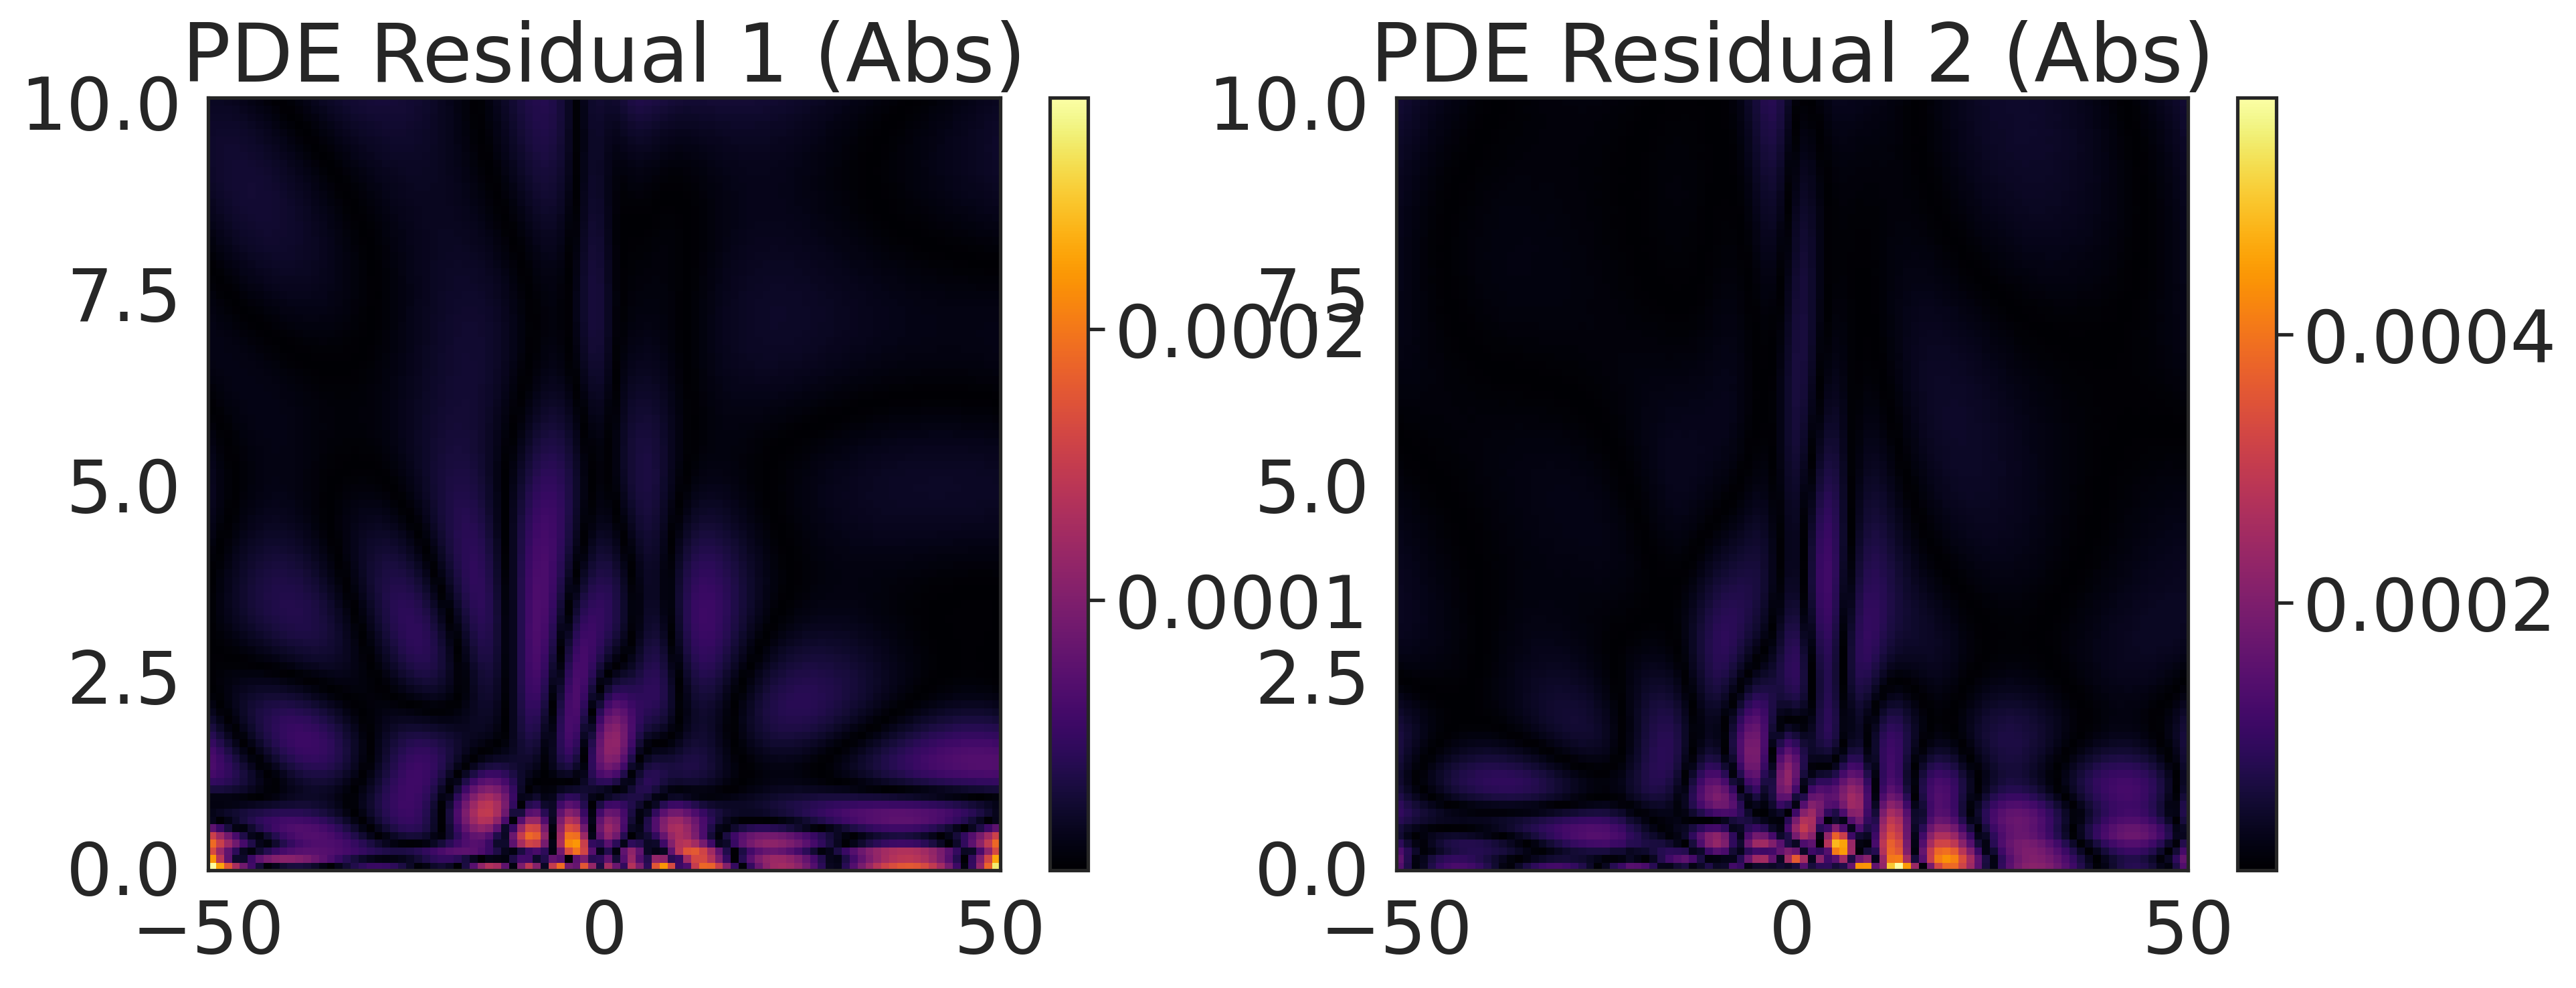

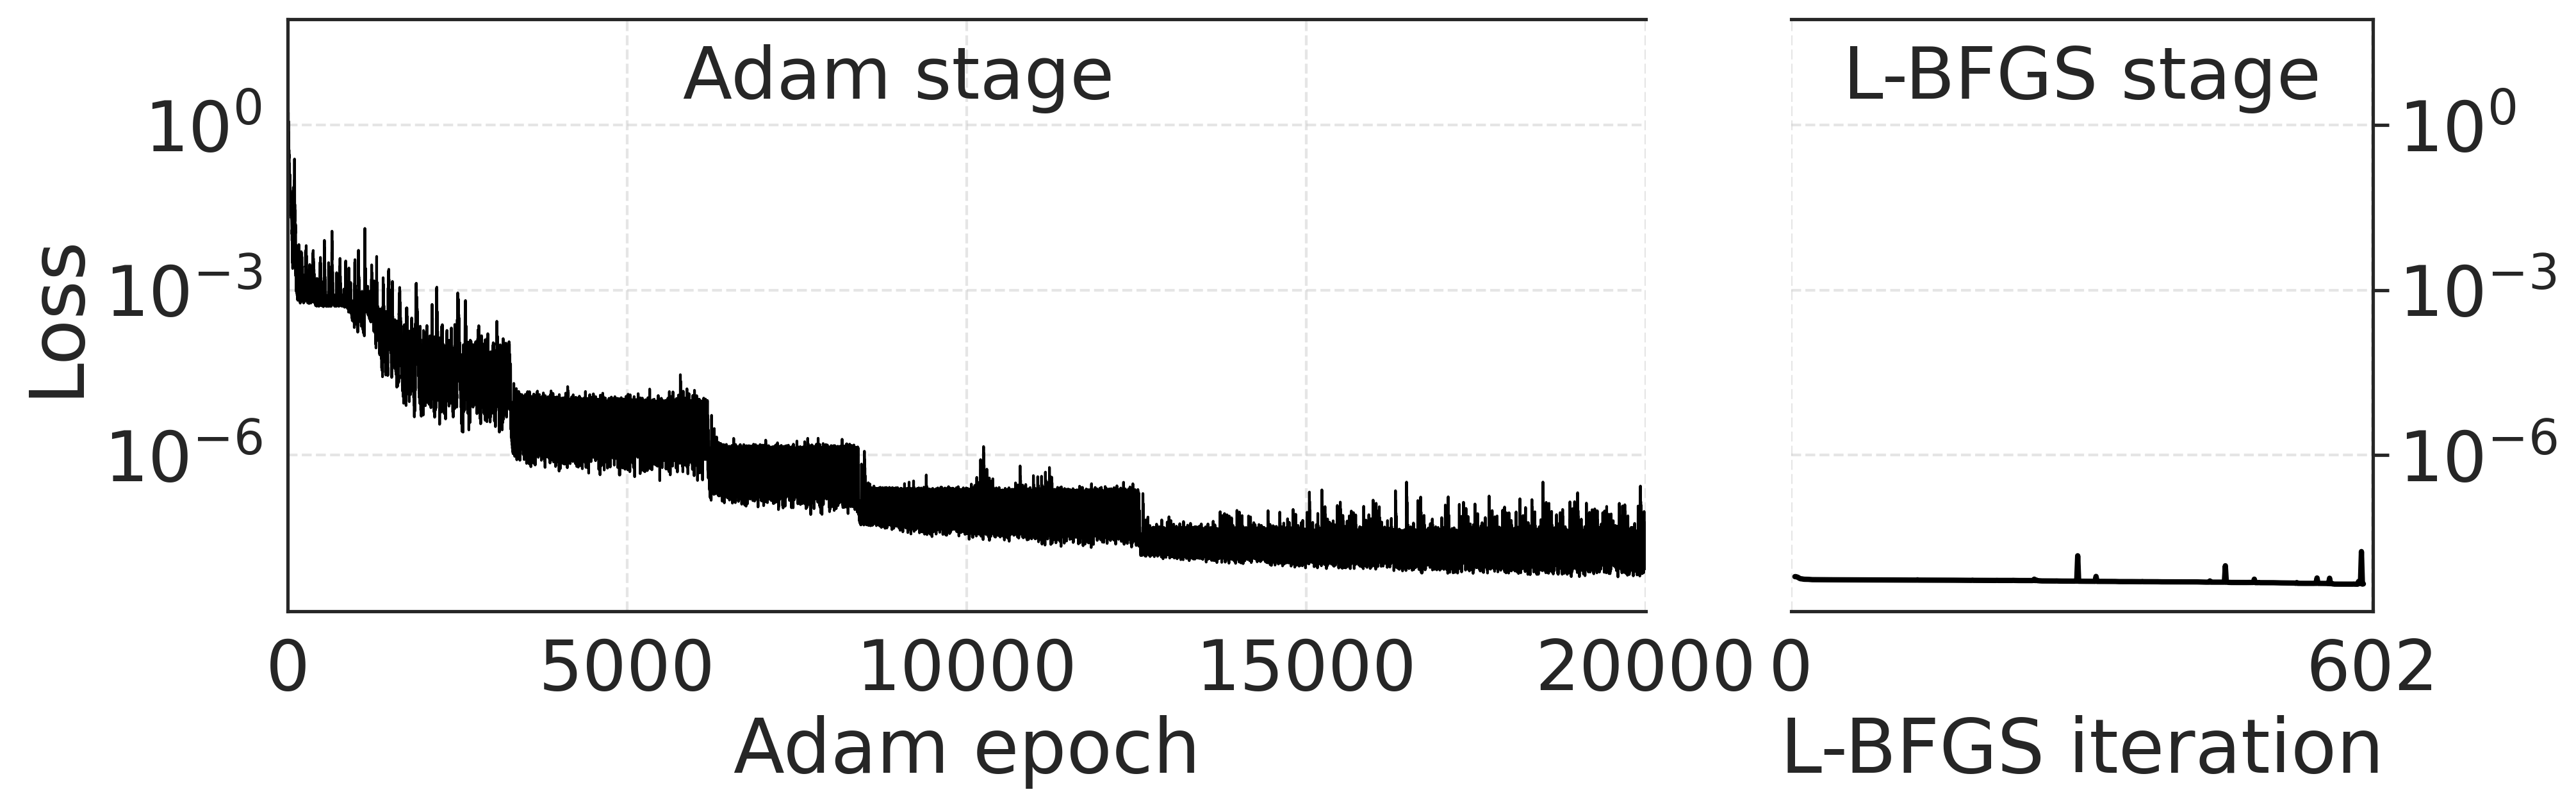

In [31]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from Plotting import plot_collocation_points, plot_combined_loss_history

# Configure fonts and LaTeX
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'

# Basic collocation plot
plot_collocation_points(X_colloc, X_ic=None, X_bc_L=None, X_bc_R=None, L=L, t_end=t_end)

# Manual grid setup
x_edges_eval = np.linspace(-L, L, 100+1)
x_eval = 0.5 * (x_edges_eval[:-1] + x_edges_eval[1:])
t_eval = np.linspace(0, t_end, 100)

# Memory-safe plotting using the grid_dump we successfully calculated in cell dm6lBTdfbsAe
if 'grid_dump' in locals():
    print("Using pre-calculated grid dump for visualization...")
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # J0 plot
    im0 = ax[0].pcolormesh(x_eval, t_eval, grid_dump['J0_grid'], shading='auto', cmap='viridis')
    ax[0].set_title('$J^0$ (Density)')
    ax[0].set_xlabel('$x$')
    ax[0].set_ylabel('$t$')
    fig.colorbar(im0, ax=ax[0])

    # Alpha plot
    alpha_grid = grid_dump['pred_grid'][:, :, 1]
    im1 = ax[1].pcolormesh(x_eval, t_eval, alpha_grid, shading='auto', cmap='magma')
    ax[1].set_title('$\\alpha$ (Fugacity)')
    ax[1].set_xlabel('$x$')
    fig.colorbar(im1, ax=ax[1])
    plt.show()

    # Residual plots
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    im2 = ax[0].pcolormesh(x_eval, t_eval, np.abs(grid_dump['r_pde_grid'][:,:,0]), shading='auto', cmap='inferno')
    ax[0].set_title('PDE Residual 1 (Abs)')
    fig.colorbar(im2, ax=ax[0])

    im3 = ax[1].pcolormesh(x_eval, t_eval, np.abs(grid_dump['r_pde_grid'][:,:,1]), shading='auto', cmap='inferno')
    ax[1].set_title('PDE Residual 2 (Abs)')
    fig.colorbar(im3, ax=ax[1])
    plt.show()
else:
    print("Error: grid_dump not found. Please run the saving cell first.")

# Loss history
lbfgs_history = {"all_inner_per_epoch": [lbfgs_loss_history]}
plot_combined_loss_history(adam_loss_history, lbfgs_history)

In [16]:
# Save all results

import os, time
import torch
import numpy as np
from typing import Dict, Any

def _as_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)

@torch.no_grad()
def _eval_on_grid(model, t_eval: np.ndarray, x_eval: np.ndarray, batch_size: int = 64):
    was_training = model.training
    model.eval()

    t_eval = np.asarray(t_eval, dtype=np.float32).ravel()
    x_eval = np.asarray(x_eval, dtype=np.float32).ravel()
    Nt, Nx = len(t_eval), len(x_eval)

    TT, XX = np.meshgrid(t_eval, x_eval, indexing='ij')
    TX = np.stack([TT.reshape(-1), XX.reshape(-1)], axis=1)

    r_list = []
    # Use small batches for gradient-based PDE residual
    with torch.enable_grad():
        for i in range(0, TX.shape[0], batch_size):
            TX_t = torch.tensor(TX[i:i+batch_size], dtype=DTYPE, device=device, requires_grad=True)
            r = model.pde_residual(TX_t)
            r_list.append(r.detach().cpu())
            del TX_t, r
            torch.cuda.empty_cache()

    r_all = torch.cat(r_list, dim=0)
    r_grid = r_all.view(Nt, Nx, -1).numpy()

    y_list = []
    with torch.no_grad():
        for i in range(0, TX.shape[0], batch_size):
            y = model(torch.tensor(TX[i:i+batch_size], dtype=DTYPE, device=device))
            if isinstance(y, (list, tuple)):
                y = torch.cat([yi if yi.ndim == 2 else yi.view(yi.shape[0], -1) for yi in y], dim=1)
            y_list.append(y.detach().cpu())
            del y
            torch.cuda.empty_cache()

    y_all = torch.cat(y_list, dim=0).numpy()
    pred_grid = y_all.reshape(Nt, Nx, -1)
    pred_names = np.array(["J0", "alpha"], dtype=object)

    J0_grid = pred_grid[:, :, 0].astype(np.float32)
    alpha_grid = pred_grid[:, :, 1].astype(np.float32)

    # Compute n from alpha and T on grid in CPU-friendly chunks
    n_grid_list = []
    for i in range(0, TX.shape[0], 512):
        t_b = torch.tensor(TX[i:i+512, 0:1], dtype=DTYPE, device=device)
        x_b = torch.tensor(TX[i:i+512, 1:2], dtype=DTYPE, device=device)
        a_b = torch.tensor(y_all[i:i+512, 1:2], dtype=DTYPE, device=device)
        T_b = T_func(t_b, x_b)
        n_b = n_from_alpha_func(a_b, T_b)
        n_grid_list.append(n_b.detach().cpu())
        del t_b, x_b, a_b, T_b, n_b

    n_grid = torch.cat(n_grid_list).view(Nt, Nx).numpy().astype(np.float32)
    torch.cuda.empty_cache()

    if was_training:
        model.train()

    return {
        "t_eval": t_eval,
        "x_eval": x_eval,
        "TX": TX.astype(np.float32),
        "r_pde_grid": r_grid,
        "pred_grid": pred_grid,
        "pred_names": pred_names,
        "J0_grid": J0_grid,
        "n_grid": n_grid,
    }

def _compute_residual_fields(model, t_eval: np.ndarray, x_eval: np.ndarray, batch_size: int = 32):
    model.eval()
    p = next(model.parameters())
    dev, dty = p.device, p.dtype
    t_eval = np.asarray(t_eval, dtype=np.float64).ravel()
    x_eval = np.asarray(x_eval, dtype=np.float64).ravel()
    Nt, Nx = len(t_eval), len(x_eval)
    tt, xx = np.meshgrid(t_eval, x_eval, indexing='ij')
    tx = np.column_stack([tt.ravel(), xx.ravel()])
    total_points = tx.shape[0]
    R1_list, R2_list, R0_list = [], [], []

    for i in range(0, total_points, batch_size):
        tx_tensor_batch = torch.tensor(tx[i:i+batch_size], dtype=dty, device=dev, requires_grad=True)
        with torch.set_grad_enabled(True):
            out_batch = model(tx_tensor_batch)
            J0_b, alpha_b = out_batch[:, 0:1], out_batch[:, 1:2]
            t_b, x_b = tx_tensor_batch[:, 0:1], tx_tensor_batch[:, 1:2]
            T_b, v_b = T_func(t_b, x_b), v_func(t_b, x_b)
            gamma_b = gamma_func(v_b)
            n_b = n_from_alpha_func(alpha_b, T_b)
            sigma_b = sigma_func(alpha_b, T_b)
            lambd_b = lambd_func(sigma_b)
            def _lg(u, inp): return torch.autograd.grad(u, inp, torch.ones_like(u), create_graph=True, retain_graph=True)[0]
            ag_b = _lg(alpha_b, tx_tensor_batch)
            at_b, ax_b = ag_b[:, 0:1], ag_b[:, 1:2]
            Jt_b = _lg(J0_b, tx_tensor_batch)[:, 0:1]
            N0_b = N_0_func(lambd_b, sigma_b, T_b, J0_b, n_b, -ax_b, v_b)
            Jx_b = Jx_func(n_b, sigma_b, lambd_b, T_b, -ax_b, N0_b, v_b)
            Jx_x_b = _lg(Jx_b, tx_tensor_batch)[:, 1:2]
            R1_list.append((Jt_b + Jx_x_b).detach().cpu())
            R2_list.append((at_b + N0_b).detach().cpu())
            h_b = at_b + v_b * ax_b
            g2_b = gamma_b**2
            dgn_dt = _lg(gamma_b*n_b, tx_tensor_batch)[:, 0:1]
            dgnv_dx = _lg(gamma_b*n_b*v_b, tx_tensor_batch)[:, 1:2]
            dlt_dt = _lg(g2_b*lambd_b*T_b*h_b, tx_tensor_batch)[:, 0:1]
            dlx_dx = _lg(g2_b*v_b*lambd_b*T_b*h_b, tx_tensor_batch)[:, 1:2]
            Wt, Wx = -at_b + g2_b*h_b, ax_b + g2_b*v_b*h_b
            dst_dt = _lg(sigma_b*T_b*Wt, tx_tensor_batch)[:, 0:1]
            dsx_dx = _lg(sigma_b*T_b*Wx, tx_tensor_batch)[:, 1:2]
            R0_list.append((dgn_dt + dgnv_dx + dlt_dt + dlx_dx - dst_dt - dsx_dx).detach().cpu())
        del tx_tensor_batch, out_batch, J0_b, alpha_b, t_b, x_b, T_b, v_b, gamma_b, n_b, sigma_b, lambd_b, ag_b, at_b, ax_b, Jt_b, N0_b, Jx_b, Jx_x_b, dgn_dt, dgnv_dx, dlt_dt, dlx_dx, dst_dt, dsx_dx
        torch.cuda.empty_cache()

    return {"R1_grid": torch.cat(R1_list).numpy().reshape(Nt, Nx), "R2_grid": torch.cat(R2_list).numpy().reshape(Nt, Nx), "R0_grid": torch.cat(R0_list).numpy().reshape(Nt, Nx)}

# Pre-evaluation cleanup
torch.cuda.empty_cache()

res_fields = _compute_residual_fields(model, t_eval=t_eval, x_eval=x_eval, batch_size=32)
grid_dump = _eval_on_grid(model, t_eval=t_eval, x_eval=x_eval, batch_size=64)
run_id = time.strftime("%Y%m%d-%H%M%S")
save_dir = os.path.abspath("./pinn_runs")
os.makedirs(save_dir, exist_ok=True)
dump_path = os.path.join(save_dir, f"PINN_run_dump_{run_id}.npz")
np.savez_compressed(dump_path, run_id=run_id, dtype=str(DTYPE), t_end=float(t_end), L=float(L), X_colloc=_as_numpy(X_colloc), x_ic=_as_numpy(x_ic), alpha_ic=_as_numpy(alpha_ic_np), J0_ic=_as_numpy(J0_ic_np), t_eval=grid_dump["t_eval"], x_eval=grid_dump["x_eval"], TX=grid_dump["TX"], pred_grid=grid_dump["pred_grid"], J0_grid=grid_dump["J0_grid"], n_grid=grid_dump["n_grid"], r_pde_grid=grid_dump["r_pde_grid"], R1_grid=res_fields["R1_grid"], R2_grid=res_fields["R2_grid"], R0_grid=res_fields["R0_grid"], adam_loss_history=np.asarray(adam_loss_history, dtype=np.float64), lbfgs_inner_curve=np.asarray(lbfgs_loss_history, dtype=np.float64))
print(f"[save] Dumped replot data to: {dump_path}")

[save] Dumped replot data to: /content/pinn_runs/PINN_run_dump_20260408-213130.npz


From the PINN output (alpha, J^0), compute n2 and scriptJ: with this, compute alpha2 and scriptJ. Do this not locally, but instead add a function at the end of BDNK_Functions.py: call it (alpha2_and_scriptJ_from_alpha_and_J0).

Then (hard part), set up PINN that: takes in (alpha2, scriptJ) as the two inputs, and outputs sigma_2 that minimizes L_IS. Give it 3 layers with 50 neurons each. For this PINN you'll write, take inspiration from basically my SA-PINN-ACTO, but removing all the SA and ACTO stuff: i.e., for example, prompt "return an almost identical copy of this code with the minimal changes that remove all the self-adaptivity (SA) stuff and all the ACTO stuff; in the end, the code should look like a normal PINN, though written like the code I'm giving you (i.e., things in the same order, same kinds of comments, etc"): everything that can remain the same should remain the same.

Then, plot the obtained sigma_2, as well as the BDNK sigma_1. (sigma_1 vs. n1 or n2?).

#### From BNDK-to-IS function

* From the BDNK PINN output ($\alpha$, $J^0$), compute $n_2$ and $\mathcal{J}$: with this, compute $\alpha_2$ and $\mathcal{J}$. Do this not locally, but instead add a function at the end of BDNK_Functions.py: call it (alpha2_and_scriptJ_from_alpha_and_J0).

In [8]:
def alpha2_and_scriptJ_from_alpha_and_J0(alpha1, t, x):
    """
    Compute the IS matching conditions (n2, alpha2, scriptJ) from a BDNK
    solution (alpha1) using Eq. IS_from_BDNK_1d:

        n2      = n1 + lambda(n1) * T * gamma * (∂_t + v ∂_x) alpha1
        scriptJ = -sigma(n1) * T * gamma * (v ∂_t + ∂_x) alpha1

    where  n1 = n(alpha1, T)  and  alpha2 = alpha(n2, T).

    Parameters
    ----------
    alpha1 : (N, 1) tensor  —  BDNK fugacity, WITH requires_grad=True
                                (so that autograd can differentiate it
                                 w.r.t. the (t, x) inputs below)
    t      : (N, 1) tensor  —  time coordinates,  requires_grad=True
    x      : (N, 1) tensor  —  space coordinates, requires_grad=True

    Returns
    -------
    alpha2  : (N, 1) tensor  —  IS fugacity (derived from n2)
    scriptJ : (N, 1) tensor  —  IS diffusion current  J (scalar component)
    n2      : (N, 1) tensor  —  IS number density
    n1      : (N, 1) tensor  —  BDNK number density (useful for plotting)
    """

    T      = T_func(t, x)          # background temperature field
    v      = v_func(t, x)          # background velocity field
    gamma  = gamma_func(v)         # Lorentz factor

    # ── BDNK density and transport coefficients ──────────────────────────
    # BUG 1 FIX: lambda_func(alpha1, T) → lambd_func(sigma1)
    #   The original code called a non-existent lambda_func(alpha1, T).
    #   lambd_func takes ONE argument (sigma), not two.
    n1     = n_from_alpha_func(alpha1, T)
    sigma1 = sigma_func(alpha1, T)
    lam1   = lambd_func(sigma1)    # λ(n1) = σ(n1) / c_ch²

    # ── Gradients of alpha1 w.r.t. (t, x) ───────────────────────────────
    # We differentiate alpha1 w.r.t. t and x separately so that the graph
    # stays clean.  (We could also cat [t,x] and slice, but separate grads
    # are more readable and avoid index confusion.)
    alpha_t = torch.autograd.grad(
        alpha1, t,
        grad_outputs=torch.ones_like(alpha1),
        create_graph=True, retain_graph=True
    )[0]                            # ∂_t α₁

    alpha_x = torch.autograd.grad(
        alpha1, x,
        grad_outputs=torch.ones_like(alpha1),
        create_graph=True, retain_graph=True
    )[0]                            # ∂_x α₁

    # ── Matching conditions (Eq. IS_from_BDNK_1d) ───────────────────────
    # n2 = n1 + λ(n1) T γ (∂_t + v ∂_x) α₁
    u_dot_grad_alpha = gamma * (alpha_t + v * alpha_x)   # u^ν ∂_ν α₁
    n2 = n1 + lam1 * T * u_dot_grad_alpha

    # scriptJ = −σ(n1) T γ (v ∂_t + ∂_x) α₁
    # BUG 5 FIX: the original code was missing the γ factor and the v*∂_t
    #   term (it set  scriptJ = -sigma1 * T * alpha_x, which is only correct
    #   for v = 0).  The full expression from the paper is:
    #       J = −σ₁ T γ (v ∂_t + ∂_x) α₁
    Delta_grad_alpha = gamma * (v * alpha_t + alpha_x)   # −Δ^{xν} ∂_ν α₁ · (−1)
    scriptJ = -sigma1 * T * Delta_grad_alpha

    # ── Invert n2 → alpha2 ───────────────────────────────────────────────
    # BUG 2 FIX: the original code called alpha_from_n(n2) which does not
    #   exist; the correct name is alpha_from_n_func(n, T).
    alpha2 = alpha_from_n_func(n2, T)

    return alpha2, scriptJ, n2, n1


# Run this function: alpha2_and_scriptJ_from_alpha_and_J0(alpha_BDNK, t_val, x_val)
# Plot alpha2, scriptJ, n2, and n1

# After this: add this function to BDNK_Functions.py script and rerun it!
# Replot alpha2, scriptJ, n2, and n1


In [34]:
# ============================================================
# CELL A  —  Add alpha2_and_scriptJ_from_alpha_and_J0
#            to BDNK_Functions.py and verify it works.
# ============================================================

# ---------- 1. Append the function to BDNK_Functions.py ----------
# We write it once; subsequent runs skip the write if it is already there.

_NEW_FUNC = '''

def alpha2_and_scriptJ_from_alpha_and_J0(alpha1, t, x):
    """
    Compute IS matching conditions from a BDNK solution.

    Implements Eq. IS_from_BDNK_1d:
        n2      = n1 + lambda(n1)*T*gamma*(d_t + v*d_x) alpha1
        scriptJ = -sigma(n1)*T*gamma*(v*d_t + d_x) alpha1
        alpha2  = alpha(n2, T)  [inverted via alpha_from_n_func]

    Parameters
    ----------
    alpha1 : (N,1) tensor  BDNK fugacity, MUST have requires_grad flowing
                           from t and x (i.e. computed from bdnk_model(tx))
    t      : (N,1) tensor  time  coords, requires_grad=True
    x      : (N,1) tensor  space coords, requires_grad=True

    Returns
    -------
    alpha2  : (N,1)  IS fugacity
    scriptJ : (N,1)  IS diffusion current J (scalar)
    n2      : (N,1)  IS number density
    n1      : (N,1)  BDNK number density
    """
    T     = T_func(t, x)
    v     = v_func(t, x)
    gamma = gamma_func(v)

    # BDNK density and transport
    n1     = n_from_alpha_func(alpha1, T)
    sigma1 = sigma_func(alpha1, T)
    # FIX: lambd_func takes sigma (one arg), not (alpha, T)
    lam1   = lambd_func(sigma1)

    # Gradients of alpha1 w.r.t. t and x separately
    alpha_t = torch.autograd.grad(
        alpha1, t,
        grad_outputs=torch.ones_like(alpha1),
        create_graph=True, retain_graph=True
    )[0]
    alpha_x = torch.autograd.grad(
        alpha1, x,
        grad_outputs=torch.ones_like(alpha1),
        create_graph=True, retain_graph=True
    )[0]

    # n2 = n1 + lambda*T*gamma*(d_t + v d_x) alpha1
    u_dot_grad_alpha   = gamma * (alpha_t + v * alpha_x)
    n2_raw = n1 + lam1 * T * u_dot_grad_alpha
    # Clamp n2 > 0 to avoid NaN in alpha_from_n_func
    n2 = torch.clamp(n2_raw, min=1e-8)

    # scriptJ = -sigma*T*gamma*(v d_t + d_x) alpha1
    # FIX: original code had -sigma*T*alpha_x only (missing gamma and v*alpha_t)
    Delta_grad_alpha = gamma * (v * alpha_t + alpha_x)
    scriptJ = -sigma1 * T * Delta_grad_alpha

    # Invert n2 -> alpha2
    # FIX: original called alpha_from_n(n2) which does not exist;
    #      correct name is alpha_from_n_func(n, T)
    alpha2 = alpha_from_n_func(n2, T)

    return alpha2, scriptJ, n2, n1
'''

import os

bdnk_path = 'BDNK_Functions.py'
with open(bdnk_path, 'r') as f:
    current = f.read()

if 'alpha2_and_scriptJ_from_alpha_and_J0' not in current:
    with open(bdnk_path, 'a') as f:
        f.write(_NEW_FUNC)
    print('Function appended to BDNK_Functions.py')
else:
    print('Function already present in BDNK_Functions.py — skipping write')

# ---------- 2. Reload the module so the new function is available ----------
import importlib, BDNK_Functions
importlib.reload(BDNK_Functions)
from BDNK_Functions import alpha2_and_scriptJ_from_alpha_and_J0
print('Module reloaded. alpha2_and_scriptJ_from_alpha_and_J0 imported.')

# ---------- 3. Quick sanity check on a single point ----------
import torch
DTYPE  = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Use a handful of collocation points to verify shapes and no NaN
_t_test = X_colloc[:20, 0:1].detach().clone().to(DTYPE).to(device).requires_grad_(True)
_x_test = X_colloc[:20, 1:2].detach().clone().to(DTYPE).to(device).requires_grad_(True)

model.eval()
for p in model.parameters():
    p.requires_grad_(False)

_tx   = torch.cat([_t_test, _x_test], dim=1)
_out  = model(_tx)
_a1   = _out[:, 1:2]  # alpha1

_a2, _sJ, _n2, _n1 = alpha2_and_scriptJ_from_alpha_and_J0(_a1, _t_test, _x_test)

assert _a2.shape  == (20, 1), f'Bad shape alpha2: {_a2.shape}'
assert _sJ.shape  == (20, 1), f'Bad shape scriptJ: {_sJ.shape}'
assert _n2.shape  == (20, 1), f'Bad shape n2: {_n2.shape}'
assert not _a2.isnan().any(),  'NaN in alpha2!'
assert not _sJ.isnan().any(),  'NaN in scriptJ!'
assert not _n2.isnan().any(),  'NaN in n2!'
assert (_n2 > 0).all(),        'n2 has non-positive values!'

print(f'Sanity check passed.')
print(f'  n1  : min={_n1.min().item():.4e}  max={_n1.max().item():.4e}')
print(f'  n2  : min={_n2.min().item():.4e}  max={_n2.max().item():.4e}')
print(f'  alpha2 : min={_a2.min().item():.4e}  max={_a2.max().item():.4e}')
print(f'  scriptJ: min={_sJ.min().item():.4e}  max={_sJ.max().item():.4e}')

Function already present in BDNK_Functions.py — skipping write
Module reloaded. alpha2_and_scriptJ_from_alpha_and_J0 imported.
Sanity check passed.
  n1  : min=1.0171e-03  max=1.0696e-03
  n2  : min=1.0498e-03  max=1.0501e-03
  alpha2 : min=1.1663e-01  max=1.1666e-01
  scriptJ: min=-1.1222e-07  max=3.8630e-08


In [35]:
# ---------- 3. Quick sanity check on a single point ----------
import torch
DTYPE  = torch.float32
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Use a handful of collocation points to verify shapes and no NaN
_t_test = X_colloc[:20, 0:1].detach().clone().to(DTYPE).to(device).requires_grad_(True)
_x_test = X_colloc[:20, 1:2].detach().clone().to(DTYPE).to(device).requires_grad_(True)

model.eval()
for p in model.parameters():
    p.requires_grad_(False)

_tx   = torch.cat([_t_test, _x_test], dim=1)
_out  = model(_tx)
_a1   = _out[:, 1:2]  # alpha1

_a2, _sJ, _n2, _n1 = alpha2_and_scriptJ_from_alpha_and_J0(_a1, _t_test, _x_test)

assert _a2.shape  == (20, 1), f'Bad shape alpha2: {_a2.shape}'
assert _sJ.shape  == (20, 1), f'Bad shape scriptJ: {_sJ.shape}'
assert _n2.shape  == (20, 1), f'Bad shape n2: {_n2.shape}'
assert not _a2.isnan().any(),  'NaN in alpha2!'
assert not _sJ.isnan().any(),  'NaN in scriptJ!'
assert not _n2.isnan().any(),  'NaN in n2!'
assert (_n2 > 0).all(),        'n2 has non-positive values!'

print(f'Sanity check passed.')
print(f'  n1  : min={_n1.min().item():.4e}  max={_n1.max().item():.4e}')
print(f'  n2  : min={_n2.min().item():.4e}  max={_n2.max().item():.4e}')
print(f'  alpha2 : min={_a2.min().item():.4e}  max={_a2.max().item():.4e}')
print(f'  scriptJ: min={_sJ.min().item():.4e}  max={_sJ.max().item():.4e}')

Sanity check passed.
  n1  : min=1.0171e-03  max=1.0696e-03
  n2  : min=1.0498e-03  max=1.0501e-03
  alpha2 : min=1.1663e-01  max=1.1666e-01
  scriptJ: min=-1.1222e-07  max=3.8630e-08


In [36]:
# ============================================================
# CELL B  —  Compute IS matching fields on the full
#            collocation grid and visualise them.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import torch

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'

# Memory-safe evaluation function
def get_matching_fields_batched(model, X_colloc, batch_size=2048):
    model.eval()
    N = X_colloc.shape[0]
    a2_list, sJ_list, n2_list, n1_list, sig1_list = [], [], [], [], []

    for i in range(0, N, batch_size):
        batch = X_colloc[i : i + batch_size].detach().clone().to(DTYPE).to(device).requires_grad_(True)
        t_b, x_b = batch[:, 0:1], batch[:, 1:2]

        # Forward
        out = model(batch)
        a1 = out[:, 1:2]

        # Matching
        a2, sJ, n2, n1 = alpha2_and_scriptJ_from_alpha_and_J0(a1, t_b, x_b)

        # Sigma1
        T_b = T_func(t_b, x_b)
        sig1 = sigma_func(a1, T_b)

        a2_list.append(a2.detach().cpu())
        sJ_list.append(sJ.detach().cpu())
        n2_list.append(n2.detach().cpu())
        n1_list.append(n1.detach().cpu())
        sig1_list.append(sig1.detach().cpu())

        del batch, out, a1, a2, sJ, n2, n1, T_b, sig1
        torch.cuda.empty_cache()

    return (torch.cat(a2_list).numpy(), torch.cat(sJ_list).numpy(),
            torch.cat(n2_list).numpy(), torch.cat(n1_list).numpy(),
            torch.cat(sig1_list).numpy())

torch.cuda.empty_cache()
alpha2_np, scriptJ_np, n2_np, n1_np, sigma1_np = get_matching_fields_batched(model, X_colloc)
alpha1_np = alpha_ic_func(X_colloc[:, 1:2]).cpu().numpy() # Approximate for visualization

# ── 4-panel summary figure ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
ax = axes.flatten()

ax[0].scatter(n1_np, n2_np, s=1, alpha=0.3, c='steelblue')
lims = [min(n1_np.min(), n2_np.min())*0.99, max(n1_np.max(), n2_np.max())*1.01]
ax[0].plot(lims, lims, 'k--', lw=1, label='n1 = n2')
ax[0].set_title('Density matching: n1 vs n2')

ax[1].scatter(n1_np, alpha2_np, s=1, alpha=0.3, c='firebrick')
ax[1].set_title('IS Fugacity alpha2 vs n1')

ax[2].scatter(n2_np, scriptJ_np, s=1, alpha=0.3, c='darkorange')
ax[2].set_title('IS diffusion current J vs n2')

idx_sort_n1 = np.argsort(n1_np.flatten())
ax[3].plot(n1_np.flatten()[idx_sort_n1], sigma1_np.flatten()[idx_sort_n1], lw=1.5, color='steelblue')
ax[3].set_title('BDNK sigma1(n1)')

plt.tight_layout()
plt.show()

RuntimeError: One of the differentiated Tensors appears to not have been used in the graph. Set allow_unused=True if this is the desired behavior.

#### Sigma PINN

* set up PINN that: takes in ($\alpha_2$, $\mathcal{J}$) as the two inputs, and outputs $\sigma_2$ that minimizes $L_{\rm IS}$;
* 3 layers with 50 neurons each.

Create the sigma PINN and make plots of it here!

In [1]:
# ============================================================
# CELL C  —  SigmaPINN definition + training
#
# Architecture: scalar n2 -> sigma2 (positive)
#   3 hidden layers x 50 neurons x tanh
#   Input normalised to [-1,1], output via softplus
#
# Loss: L_IS = <R1^2 + R2^2> where
#   R1 = d_t n2 + d_x scriptJ
#   R2 = tau_J * d_t scriptJ + scriptJ + sigma2*T*d_x alpha2
#        + (sigma2*T/2) * scriptJ * d_t[tau_J/(sigma2*T)]
#
# Training: Adam (5000 epochs) + L-BFGS (500 iters)
# ============================================================

import torch
import torch.nn as nn
import time

# ── 1. SigmaPINN class  ───────────────────────────────────────────────────
# Written in the same style as SA_PINN_ACTO.py, with SA and ACTO removed.

class SigmaPINN(nn.Module):
    def __init__(self, Nl=3, Nn=50, lb_n=None, ub_n=None):
        super().__init__()

        # Input normalisation: maps n2 from [lb_n, ub_n] to [-1, 1]
        # (same pattern as PINN_BDNK_1D._scale)
        if lb_n is not None and ub_n is not None:
            self.register_buffer('lb_n',
                torch.as_tensor(lb_n, dtype=torch.get_default_dtype()))
            self.register_buffer('ub_n',
                torch.as_tensor(ub_n, dtype=torch.get_default_dtype()))
        else:
            self.lb_n = None
            self.ub_n = None

        # Base network: n2 (scalar) -> sigma2 (scalar, positive)
        self.net = nn.Sequential()
        self.net.add_module('Linear_layer_1', nn.Linear(1, Nn))
        self.net.add_module('Tanh_layer_1',   nn.Tanh())
        for num in range(2, Nl + 1):
            self.net.add_module(f'Linear_layer_{num}', nn.Linear(Nn, Nn))
            self.net.add_module(f'Tanh_layer_{num}',   nn.Tanh())
        self.net.add_module('Linear_layer_final', nn.Linear(Nn, 1))

    def _scale(self, n2):
        """Map n2 from physical units to [-1, 1]."""
        if self.lb_n is not None and self.ub_n is not None:
            return 2.0 * (n2 - self.lb_n) / (self.ub_n - self.lb_n) - 1.0
        return n2

    def forward(self, n2):
        """n2 : (N,1) -> sigma2 : (N,1), positive via softplus."""
        return nn.functional.softplus(self.net(self._scale(n2)))


# ── 2. IS loss function  ──────────────────────────────────────────────────
# Standalone function, outside the class (same pattern as pde_residual).
# Recomputes the full chain (t,x)->alpha1->matching->residuals each call
# so that gradients flow back through sigma_model.

def IS_pde_residual(sigma_model, bdnk_model, t, x):
    """
    Compute R1, R2 of the IS equations at collocation points (t, x).

    All intermediate tensors are differentiable w.r.t. sigma_model params
    because the chain is:
        (t,x) -> bdnk_model -> alpha1 -> matching -> (n2, scriptJ, alpha2)
             -> sigma_model(n2) -> (tau_J, R1, R2)

    Parameters
    ----------
    sigma_model : SigmaPINN  (being trained)
    bdnk_model  : PINN_BDNK_1D  (frozen)
    t, x        : (N,1) tensors, requires_grad=True

    Returns
    -------
    loss   : scalar
    R1_abs : (N,1) detached  |charge conservation residual|
    R2_abs : (N,1) detached  |IS relaxation residual|
    """

    def _grad(u, wrt):
        return torch.autograd.grad(
            u, wrt,
            grad_outputs=torch.ones_like(u),
            create_graph=True, retain_graph=True
        )[0]

    # Step 1: BDNK forward (with gradient flowing through t, x)
    tx       = torch.cat([t, x], dim=1)
    out_bdnk = bdnk_model(tx)          # [J0, alpha1]
    alpha1   = out_bdnk[:, 1:2]

    # Step 2: IS matching conditions
    alpha2, scriptJ, n2, n1 = \
        alpha2_and_scriptJ_from_alpha_and_J0(alpha1, t, x)

    T = T_func(t, x)

    # Step 3: sigma2 from the network being trained
    sigma2 = sigma_model(n2)                              # (N,1), > 0
    tau2   = 12.0 * sigma2 * T / n2.clamp(min=1e-8)      # relaxation time

    # Step 4: gradients of IS fields w.r.t. t and x
    dn2_dt      = _grad(n2,      t)
    dJ_dx       = _grad(scriptJ, x)
    dJ_dt       = _grad(scriptJ, t)
    dalpha2_dx  = _grad(alpha2,  x)

    # R1 = d_t n2 + d_x J  (charge conservation)
    R1 = dn2_dt + dJ_dx

    # R2 = tau_J*d_t J + J + (sigma2*T/2)*J*d_t[tau/(sigma*T)] + sigma2*T*d_x alpha2
    # The extra term (sigma2*T/2)*J*d_t[tau/(sigma*T)]
    # = (sigma2*T/2)*J * (-12/n2^2) * d_t n2 = -6*sigma2*T/n2^2 * J * d_t n2
    # This is the term that was wrongly included in the original buggy SigmaPINN.
    # Here we include it correctly.
    tau_over_sigT   = tau2 / (sigma2 * T).clamp(min=1e-12)    # = 12/n2
    d_tauSigT_dt    = _grad(tau_over_sigT, t)
    extra           = 0.5 * sigma2 * T * scriptJ * d_tauSigT_dt

    R2 = tau2 * dJ_dt + scriptJ + extra + sigma2 * T * dalpha2_dx

    loss = torch.mean(R1**2 + R2**2)
    return loss, R1.detach().abs(), R2.detach().abs()


# ── 3. Normalisation bounds for n2  ──────────────────────────────────────
lb_n_val = float(n2_np.min()) - 1e-8
ub_n_val = float(n2_np.max()) + 1e-8
print(f'n2 range used for SigmaPINN normalisation: [{lb_n_val:.4e}, {ub_n_val:.4e}]')

# ── 4. Instantiate model  ─────────────────────────────────────────────────
sigma_model = SigmaPINN(
    Nl=3, Nn=50,
    lb_n=lb_n_val,
    ub_n=ub_n_val,
).to(device).to(DTYPE)

# Xavier normal init (same as SA_PINN_ACTO)
def glorot_sigma(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_normal_(m.weight, gain=1.0)
        if m.bias is not None: nn.init.zeros_(m.bias)
sigma_model.apply(glorot_sigma)
print(f'SigmaPINN: {sum(p.numel() for p in sigma_model.parameters())} parameters')

# ── 5. Optimisers  ───────────────────────────────────────────────────────
from torch.optim.lr_scheduler import ReduceLROnPlateau

lr_sigma     = 1e-3
adam_epochs  = 5_000

optimizer_sigma = torch.optim.Adam(
    sigma_model.parameters(), lr=lr_sigma, betas=(0.9, 0.95)
)
scheduler_sigma = ReduceLROnPlateau(
    optimizer_sigma, mode='min', factor=0.4,
    patience=300, threshold=1e-4, min_lr=lr_sigma / 100,
)

# ── 6. Adam training loop  ───────────────────────────────────────────────
print(f'\nStarting SigmaPINN Adam training ({adam_epochs} epochs)...')
sigma_adam_history = []
best_sigma_loss    = float('inf')
best_sigma_state   = None

t0_sigma = time.time()

for epoch in range(1, adam_epochs + 1):
    optimizer_sigma.zero_grad()

    # Rebuild requires_grad tensors every epoch so the graph is fresh
    t_e = t_col.detach().clone().requires_grad_(True)
    x_e = x_col.detach().clone().requires_grad_(True)

    loss, R1_abs, R2_abs = IS_pde_residual(sigma_model, model, t_e, x_e)

    if not torch.isfinite(loss):
        print(f'  Epoch {epoch}: non-finite loss, stopping Adam.')
        break

    loss.backward()
    nn.utils.clip_grad_norm_(sigma_model.parameters(), max_norm=1.0)
    optimizer_sigma.step()
    scheduler_sigma.step(loss.item())

    flt = loss.item()
    sigma_adam_history.append(flt)

    if flt < best_sigma_loss:
        best_sigma_loss  = flt
        best_sigma_state = {k: v.detach().cpu().clone()
                            for k, v in sigma_model.state_dict().items()}

    if epoch % 500 == 0 or epoch == adam_epochs:
        lr_now = optimizer_sigma.param_groups[0]['lr']
        print(f'  Epoch {epoch:5d}/{adam_epochs}  '
              f'loss={flt:.4e}  '
              f'<|R1|>={R1_abs.mean().item():.3e}  '
              f'<|R2|>={R2_abs.mean().item():.3e}  '
              f'lr={lr_now:.2e}')

adam_sigma_time = time.time() - t0_sigma
print(f'\nAdam done in {adam_sigma_time:.1f}s  |  best loss = {best_sigma_loss:.4e}')

if best_sigma_state is not None:
    sigma_model.load_state_dict(best_sigma_state)

# ── 7. L-BFGS fine-tuning  ───────────────────────────────────────────────
print('\nStarting L-BFGS fine-tuning...')

with torch.enable_grad():
    _t_init = t_col.detach().clone().requires_grad_(True)
    _x_init = x_col.detach().clone().requires_grad_(True)
    _init_loss, _, _ = IS_pde_residual(sigma_model, model, _t_init, _x_init)
loss_scale_sigma = 1.0 / max(_init_loss.item(), 1e-30)
print(f'  L-BFGS initial loss: {_init_loss.item():.4e}  (scale factor: {loss_scale_sigma:.4e})')

optimizer_lbfgs_sigma = torch.optim.LBFGS(
    sigma_model.parameters(),
    lr=1.0, max_iter=500, max_eval=500,
    history_size=50, line_search_fn=None,
    tolerance_grad=1e-10, tolerance_change=1e-12,
)

sigma_lbfgs_history = []
best_lbfgs_sigma    = {'loss': float('inf'), 'state': None}

def sigma_closure():
    optimizer_lbfgs_sigma.zero_grad(set_to_none=True)
    t_e = t_col.detach().clone().requires_grad_(True)
    x_e = x_col.detach().clone().requires_grad_(True)
    loss, _, _ = IS_pde_residual(sigma_model, model, t_e, x_e)
    if not torch.isfinite(loss):
        raise RuntimeError('L-BFGS_NAN')
    (loss * loss_scale_sigma).backward()
    flt = loss.item()
    sigma_lbfgs_history.append(flt)
    if flt < best_lbfgs_sigma['loss']:
        best_lbfgs_sigma['loss']  = flt
        best_lbfgs_sigma['state'] = {k: v.detach().cpu().clone()
                                     for k, v in sigma_model.state_dict().items()}
    return loss * loss_scale_sigma

t1_sigma = time.time()
try:
    optimizer_lbfgs_sigma.step(sigma_closure)
except RuntimeError as e:
    if 'L-BFGS_NAN' in str(e):
        print('  L-BFGS stopped early (NaN detected).')
    else:
        raise
lbfgs_sigma_time = time.time() - t1_sigma

print(f'L-BFGS done in {lbfgs_sigma_time:.1f}s  |  best loss = {best_lbfgs_sigma["loss"]:.4e}')

if best_lbfgs_sigma['state'] is not None:
    sigma_model.load_state_dict(best_lbfgs_sigma['state'])
    print('Best L-BFGS state restored.')

print(f'\nTotal SigmaPINN training: {time.time()-t0_sigma:.1f}s')
print(f'  Adam:   {adam_sigma_time:.1f}s')
print(f'  L-BFGS: {lbfgs_sigma_time:.1f}s')

NameError: name 'n2_np' is not defined

sigma2 range: [1.4669e-03, 2.0306e-01]
sigma1 range: [2.6623e-03, 2.6665e-03]


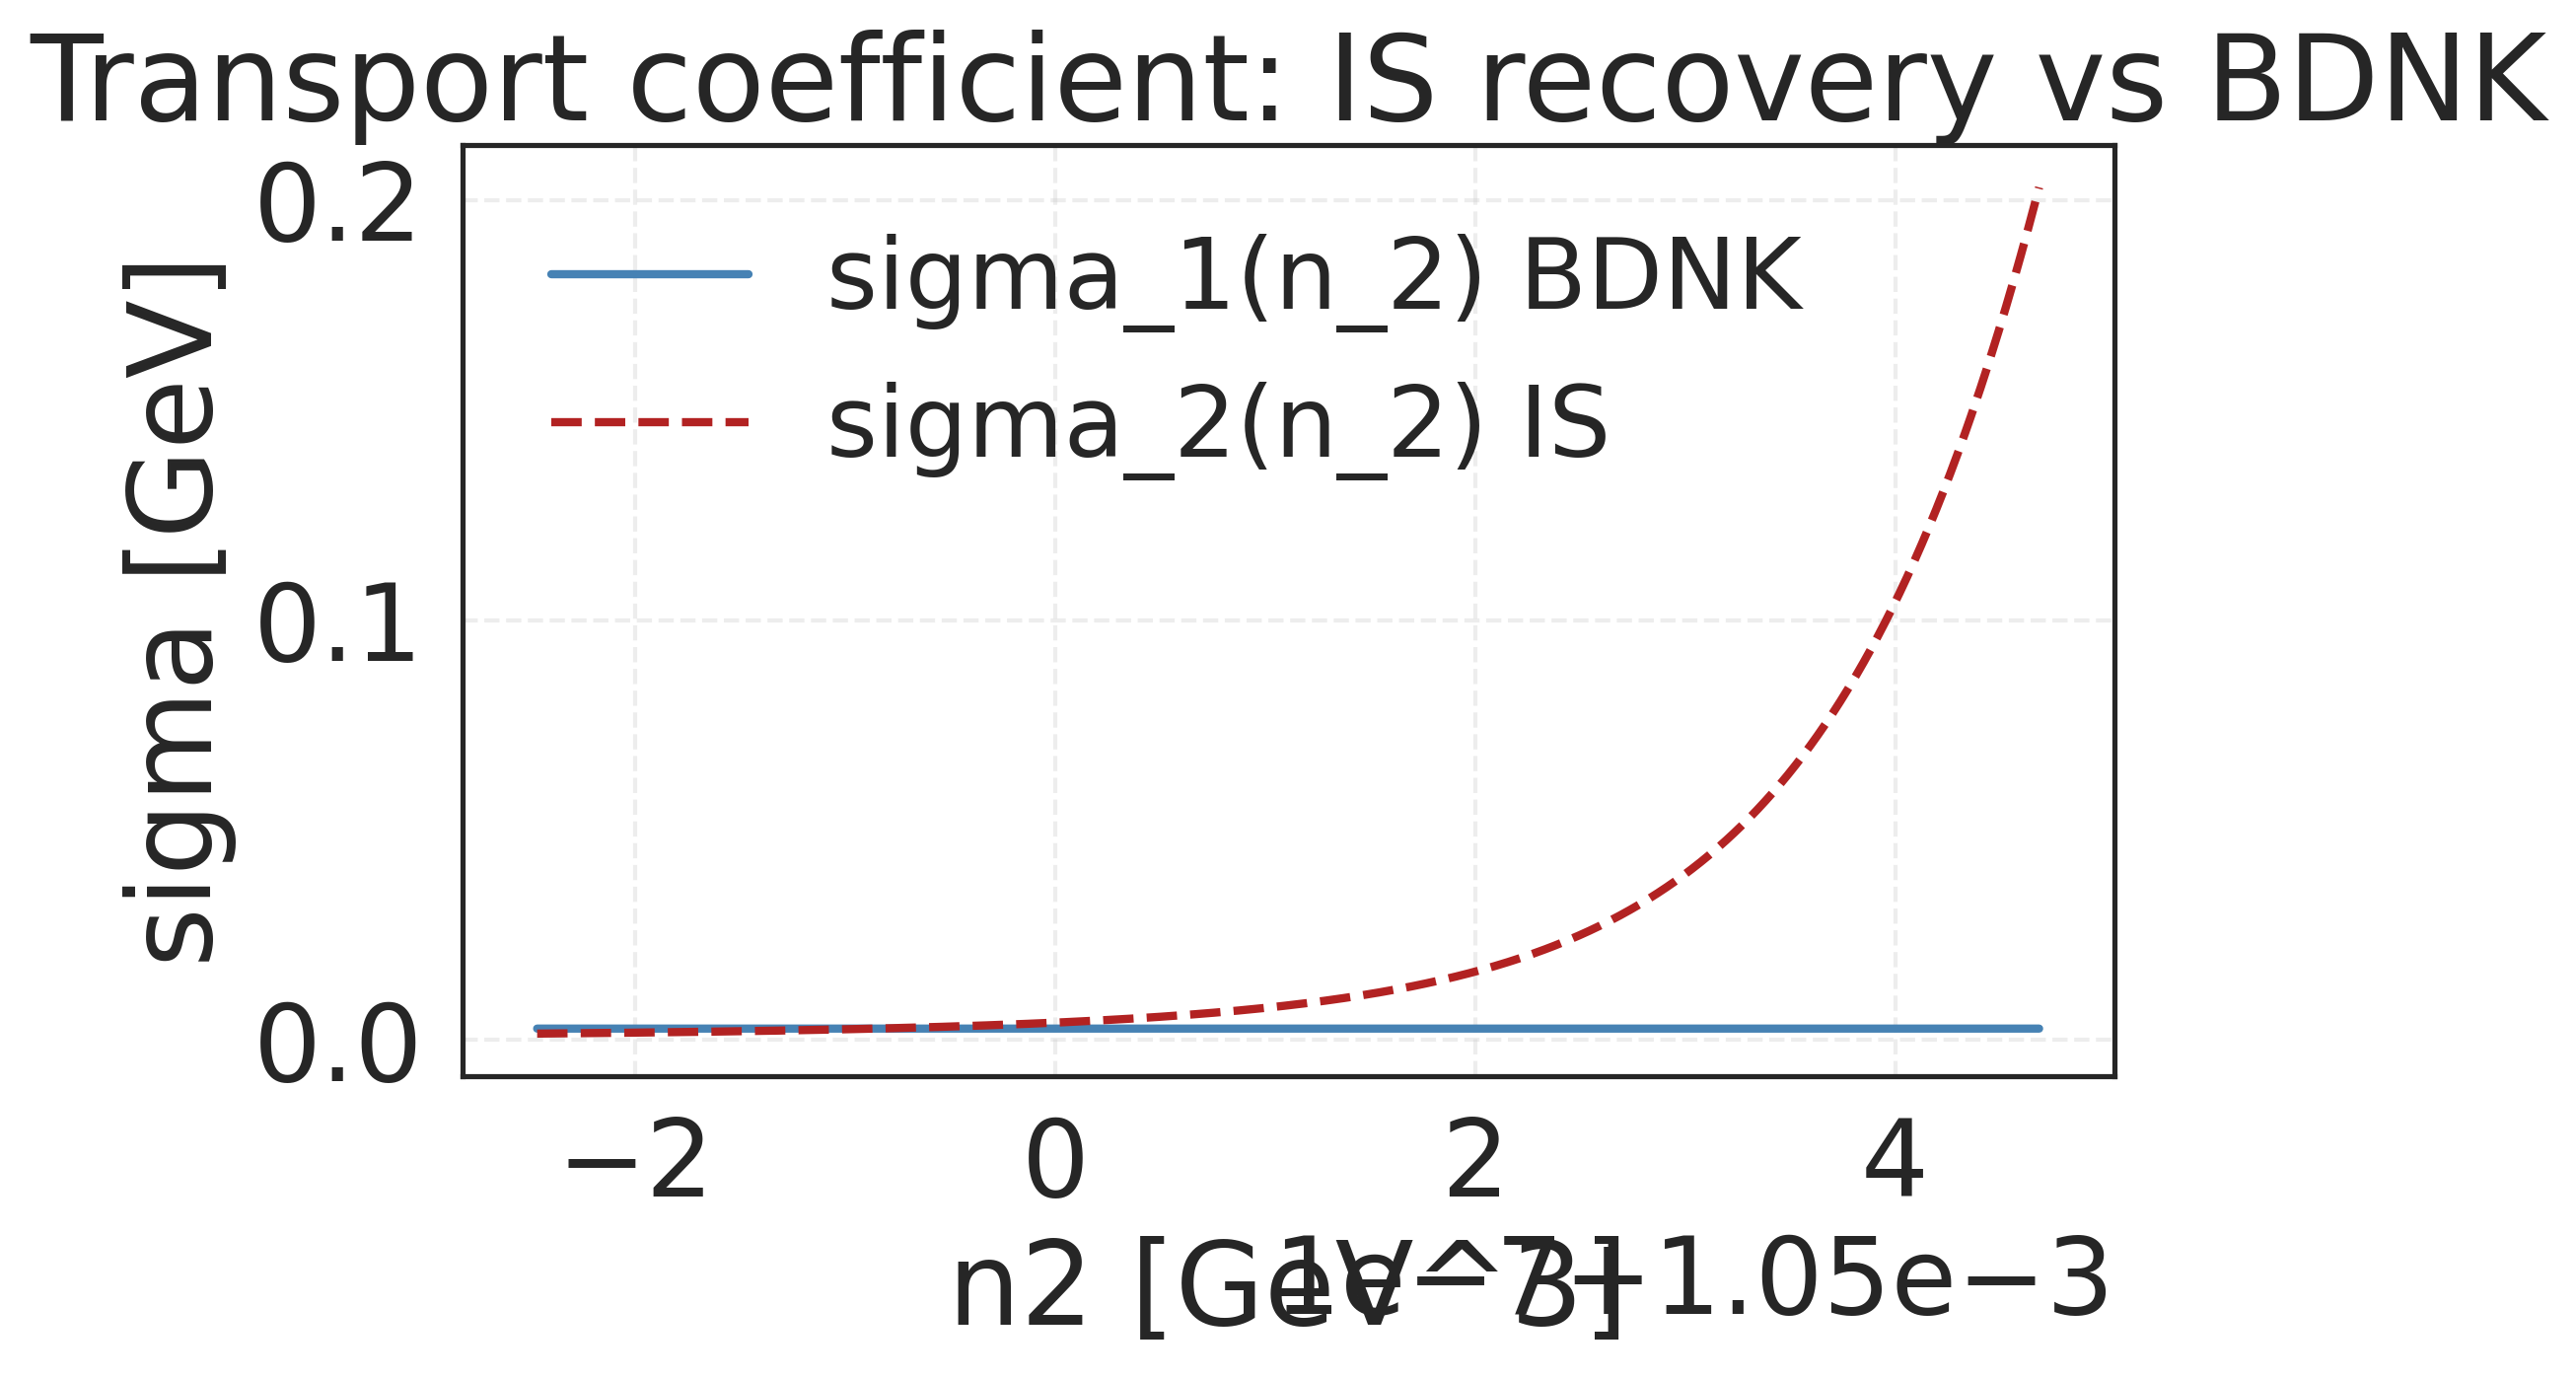

In [30]:
# ============================================================
# CELL D  —  All diagnostic plots
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator

plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif' # Resolve font warnings
sigma_model.eval()

# ── Evaluate sigma2 at all collocation points ──────────────────────────
with torch.no_grad():
    n2_t     = torch.tensor(n2_np.reshape(-1,1), dtype=DTYPE, device=device)
    sigma2_np = sigma_model(n2_t).cpu().numpy().flatten()

print(f'sigma2 range: [{sigma2_np.min():.4e}, {sigma2_np.max():.4e}]')
print(f'sigma1 range: [{sigma1_np.min():.4e}, {sigma1_np.max():.4e}]')

# PLOT 1: sigma2(n2) vs sigma1(n1)
with torch.no_grad():
    from BDNK_Functions import alpha_from_n_func, T_func
    T_val   = 0.3
    T_const = torch.tensor([[T_val]], dtype=DTYPE, device=device).expand_as(n2_t)
    a_at_n2 = alpha_from_n_func(n2_t, T_const)
    s1_at_n2 = sigma_func(a_at_n2, T_const).cpu().numpy().flatten()

idx_s = np.argsort(n2_np)

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(n2_np[idx_s], s1_at_n2[idx_s], lw=2.0, color='steelblue', label=r'sigma_1(n_2) BDNK')
ax.plot(n2_np[idx_s], sigma2_np[idx_s], lw=2.0, color='firebrick', ls='--', label=r'sigma_2(n_2) IS')
ax.set_xlabel('n2 [GeV^3]')
ax.set_ylabel('sigma [GeV]')
ax.set_title('Transport coefficient: IS recovery vs BDNK')
ax.legend(frameon=False)
ax.grid(True, which='both', ls='--', alpha=0.35)
plt.tight_layout()
plt.show()